In [2]:
%matplotlib inline
import numpy as np
import sklearn.linear_model
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['figure.dpi'] = 200
import matplotlib.colors as colors
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import numpy.linalg as la
import os
import seaborn as sns
from sklearn.metrics import r2_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import StepLR
from pathlib import Path
from scipy.stats import norm
import statistics

In [3]:
#Fills in NaN values in y_session

path = r"C:\Users\andre\Desktop\active_neuron\data\sample_photostim_59_spatial_date_070623.npy"
data = np.load(path, allow_pickle = True).item() #dict

for key in data.keys():
    print(key)

print(data['o1'].shape) #(10,100)

y_session = data['y_session']  #np.ndarray photostimulation intensity value (t, neurons)
u_session = data['u_session']  #np.ndarray t:t+3 is 1 for stimulated (t, neurons)

y_session_interp = y_session.copy()
for i in range(y_session.shape[1]):  #i loop over neurons
    nan_start = -1
    nan_stop = -1
    for j in range(y_session.shape[0]):  #j loop over t
        if nan_start == -1 and np.isnan(y_session_interp[j,i]):  #if no nan detected yet and 1 is detected
            nan_start = j - 1  # set nan_start to 1 t before detected index
        if nan_start != -1 and not np.isnan(y_session_interp[j,i]):  # if nan has been detected previously and no longer detected
            nan_stop = j  #set nan_stop to t
        if nan_start != -1 and nan_stop != -1: #if a valid nan interval has been detected
            slope = y_session_interp[nan_stop,i] - y_session_interp[nan_start,i]
            for k in range(nan_stop - nan_start - 1):  #linearly interpolate the detected nan interval, in the y_session data
                y_session_interp[nan_start + k + 1,i] = slope*k/(nan_stop-nan_start-1) + y_session_interp[nan_start,i]
            nan_start = -1
            nan_stop = -1


u_session
u_spatial_session
y_session
x1
x2
o1
o2
(10, 100)


(502,) idx is a np.array of size n with the actual n's as the values
(502,) on is a np.array boolean mask of size n with trues and falses of if that neuron is above 0 or not (stimulated or not)
[  2  17  21  60  67  75 105 129 149 196 273] pattern is now the neurons at t which were non-zero
added this pattern: [  2  17  21  60  67  75 105 129 149 196 273]
pattern count is now [1]
added pattern index [[1]]
pattern length is now [11]
 
(502,) idx is a np.array of size n with the actual n's as the values
(502,) on is a np.array boolean mask of size n with trues and falses of if that neuron is above 0 or not (stimulated or not)
[  4  75  95  98 108 164 170 173 226 257 279 319 367] pattern is now the neurons at t which were non-zero
added this pattern: [  4  75  95  98 108 164 170 173 226 257 279 319 367]
pattern count is now [1, 1]
added pattern index [[1], [15]]
pattern length is now [11, 13]
 
(502,) idx is a np.array of size n with the actual n's as the values
(502,) on is a np.array bo

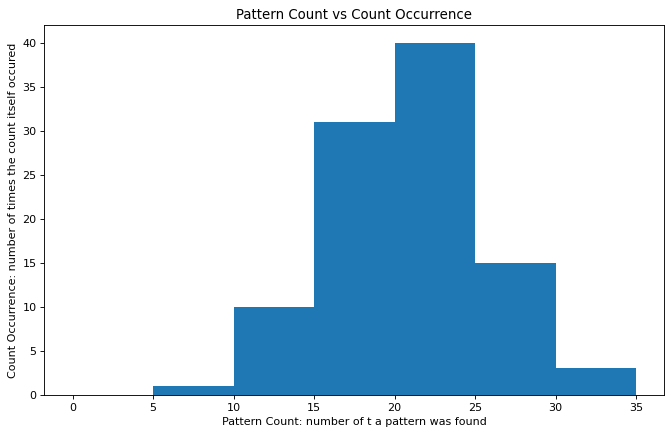

In [4]:
#Pattern counting, a pattern is the non-zero/stimulated neurons

patterns = []
pattern_count = []
pattern_idx = []
pattern_length = []

start = -10
for t in range(u_session.shape[0]):  #loop through t

    #if there is a single non_zero element in t-th row of u_session 
    #and if t is more than 4 units greater than start
    if np.sum(np.abs(u_session[t,:])) > 0 and t > start + 4:

        idx = np.linspace(0,u_session.shape[1]-1,u_session.shape[1]).astype(int)
        print(f"{idx.shape} idx is a np.array of size n with the actual n's as the values")

        on = u_session[t,:] > 0
        print(f"{on.shape} on is a np.array boolean mask of size n with trues and falses of if that neuron is above 0 or not (stimulated or not)")

        pattern = np.array(idx[on])
        print(f"{pattern} pattern is now the neurons at t which were non-zero")

        start = t  #set start to the current trial we are on
        found = False
        for i in range(len(patterns)):

            # if pattern has been found already
            if len(pattern) == len(patterns[i]):
                if np.linalg.norm(pattern - patterns[i]) == 0:
                    pattern_count[i] += 1
                    pattern_idx[i].append(t)
                    found = True
                    break

        # if pattern has not been found yet
        if found is False:
            patterns.append(pattern)  #there are 100 patterns
            pattern_count.append(1)
            pattern_idx.append([t])  #append the trial as the pattern_idx
            pattern_length.append(len(pattern))

            print(f"added this pattern: {pattern}")
            print(f"pattern count is now {pattern_count}")
            print(f"added pattern index {pattern_idx}")
            print(f"pattern length is now {pattern_length}")
            print(" ")

print(f"patterns should be {len(patterns)} long")
print(f"pattern_count is the number of times each pattern was found.{pattern_count}")
print(f"pattern_idx is all the t's that each pattern was found at, so this is going to be 100 sub arrays of a bunch of t's {pattern_idx}")
print(f"pattern_length is the lengths of all patterns found. {pattern_length}")

#counting how many patterns each neuron is involved in, store in neuron_pattern
neuron_pattern = np.zeros(u_session.shape[1])
for i in range(u_session.shape[1]):
    for p in patterns:
        if i in p:
            neuron_pattern[i] += 1

plt.figure(figsize=(10, 6), dpi=80)
plt.hist(pattern_count, bins=[0,5,10,15,20,25,30,35])
plt.title("Pattern Count vs Count Occurrence")
plt.xlabel('Pattern Count: number of t a pattern was found')
plt.ylabel('Count Occurrence: number of times the count itself occured')
plt.show()

#(20, 10) means there are 10 unique patterns 
#that occurred exactly 20 times across all trials

In [5]:
idx = np.linspace(0,u_session.shape[1]-1,u_session.shape[1]).astype(int)
print(f"{idx.shape} idx is a np.array of size n with the actual n's as the values")

# This will be 502 trues and falses
on = u_session[1,:] > 0
print(f"{on.shape} on is a np.array of size n with trues and falses of if that neuron is above 0 or not")

print(idx[on])
print(f"{pattern} pattern is now the neurons at t which were non-zero")

(502,) idx is a np.array of size n with the actual n's as the values
(502,) on is a np.array of size n with trues and falses of if that neuron is above 0 or not
[  2  17  21  60  67  75 105 129 149 196 273]
[ 80 110 111 139 144 177 196 216 219 321 469 485] pattern is now the neurons at t which were non-zero


### Train-Test Split ###

- remove 5 patterns each which looks like [63, 65, 95, 98, 124, 265, 279, 312, 367, 386, 399, 403, 484, 486, 489].

- loop through every t that each pattern happens at which looks like [1, 1331, 3293, 3423, 6683, 7027, 10538, 14364, 16006, 19633, 20631, 21900, 23637, 24467, 24966, 25853, 26282, 26354, 27601]
and remove 20 t steps before it and 50 t steps after it

pattern id: 44
removed pattern indexes are now [44]
total removed pattern count is now 17
total removed neurons are now [63, 65, 95, 98, 124, 265, 279, 312, 367, 386, 399, 403, 484, 486, 489]
pattern id: 47
removed pattern indexes are now [44, 47]
total removed pattern count is now 37
total removed neurons are now [63, 65, 95, 98, 124, 265, 279, 312, 367, 386, 399, 403, 484, 486, 489, 1, 33, 49, 67, 95, 129, 196, 265, 279, 342, 367, 419]
pattern id: 64
removed pattern indexes are now [44, 47, 64]
total removed pattern count is now 57
total removed neurons are now [63, 65, 95, 98, 124, 265, 279, 312, 367, 386, 399, 403, 484, 486, 489, 1, 33, 49, 67, 95, 129, 196, 265, 279, 342, 367, 419, 76, 194, 223, 230, 236, 242, 293, 322, 359, 385, 461]
pattern id: 67
removed pattern indexes are now [44, 47, 64, 67]
total removed pattern count is now 76
total removed neurons are now [63, 65, 95, 98, 124, 265, 279, 312, 367, 386, 399, 403, 484, 486, 489, 1, 33, 49, 67, 95, 129, 196, 265, 279, 342, 36

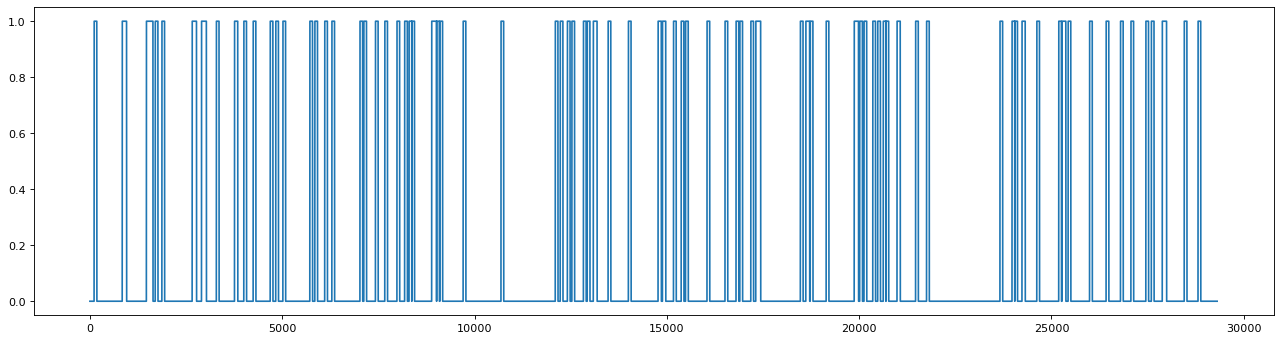

EX of pattern_idx[p_idx] will be a series of t's where this pattern occurred [861, 1546, 3780, 4022, 5738, 8906, 9724, 12950, 14792, 14921, 20374, 20717, 21018, 24253, 24267, 25452, 26010]
117 t's and intervals of t-20:t+50 for each one of these was marked for test set ~roughly, some at end left out
train set is 22968 1's in a np.array 29308 long.
test set is 6340 1's in a np.array 29308 long.


In [6]:
# remove patterns randomly
# ??? Why only 5 patterns?
num_patterns = 5
removed_patterns = []
removed_neurons = []
removed_steps = np.zeros(u_session.shape[0])
removed_count = 0

np.random.seed(0)
while len(removed_patterns) < num_patterns:  # while the patterns are NOT all removed
    p_idx = np.random.randint(0,len(patterns))  #pick random pattern index, 1-100
    print('pattern id:', p_idx)
    if p_idx not in removed_patterns:
        removed_patterns.append(p_idx)
        removed_count += pattern_count[p_idx]  # += will be a number like 22
        print(f"removed pattern indexes are now {removed_patterns}")
        print(f"total removed pattern count is now {removed_count}")
        
        #add each [1,99,500, etc.] pattern of neurons at p_idx to removed_neurons
        removed_neurons.extend(patterns[p_idx])
        print(f"total removed neurons are now {removed_neurons}")

        #looping through the t's the pattern at p_idx occurred at
        #remove interval from 20 before t to 50 after t
        for i in pattern_idx[p_idx]:  
            min_idx = np.max([0,i-20])
            max_idx = np.min([i+50,u_session.shape[0]-1])
            #marked all t's in this interval for removal with a 1
            removed_steps[min_idx:max_idx] = 1

print(f"print the number of removed t's {np.sum(removed_steps)}")
print(f"print total removed pattern count {removed_count} and print the fraction of removed t's {np.sum(removed_steps) / u_session.shape[0]}")
print(f"print the removed pattern indexes {removed_patterns}")
plt.figure(figsize=(20,5), dpi=80)
plt.plot(removed_steps)
plt.show()

#set the removed steps as the test set
test_indices = removed_steps.astype(int)

#set the non removed steps as the train set
train_indices = np.ones(test_indices.shape[0]).astype(int) - test_indices.copy()
removed_neurons = list(set(removed_neurons))

print(f"EX of pattern_idx[p_idx] will be a series of t's where this pattern occurred {pattern_idx[44]}")
print(f"{len(pattern_idx[44] + pattern_idx[44] + pattern_idx[47] + pattern_idx[64] + pattern_idx[67] + pattern_idx[9])} t's and intervals of t-20:t+50 for each one of these was marked for test set ~roughly, some at end left out")

print(f"train set is {np.sum(train_indices)} 1's in a np.array {len(train_indices)} long.")
print(f"test set is {np.sum(test_indices)} 1's in a np.array {len(test_indices)} long.")

train_test_split = {}
train_test_split['train_indices'] = train_indices
train_test_split['test_indices'] = test_indices
# np.save('train_test_split',train_test_split)

In [7]:
# Closed Form Linear Regression TODO: I think this would be equivalent to the full rank AR-k model, run the LinearDynamicModel code above to compare.

print(f"there are {len(train_indices)} t's total")
print(f"{np.sum(train_indices)} of those are training t's")
print(f"{np.sum(test_indices)} of those are test t's")

ark_order = 4  # models predictions are seeded with first k=4 steps of population activity, then given full time series of stimulation input to all neurons, prediction made
normalize = 1000
X = []
Xp = []
# train_indices here is 29308, full length
for t in range(train_indices.shape[0]-ark_order):  # 29304
    if np.sum(train_indices[t:t+ark_order+1]) == ark_order + 1 and t > 5 + ark_order:  #if it is valid training data only 22636 valid training indices
        # X.append( (4 * 502) + (4 * 502) + 1 = 4017) 
        # X is all the (concatted previous t:t+4 x's and t:t+4 u's) appended for each t
        # Xp.append( (502) ) = Xp is all the t+4 states appended; the t+4 state is the state we want to predict
        X.append(np.concatenate((y_session_interp[t:t+ark_order,:].copy().flatten()/normalize, u_session[t:t+ark_order,:].copy().flatten(),np.ones(1))))  # concatenating a 1 for y = Xw + b, bias term
        Xp.append(y_session_interp[t+ark_order,:].copy().flatten()/normalize)

print(f"There are only {len(X)} valid training indices or t's.")
X = np.array(X)  # (22636, 4017)
Xp = np.array(Xp)  # (22636, 502) basically our y
print(f"for t in 22636 valid training t's: X.append( (4 * 502) + (4 * 502) + 1 ) to get X with shape {X.shape}")
print(f"for t in 22636 valid training t's Xp.append( (502) ) to get X_pred with shape{Xp.shape}")

# W = (X.T @ X)^-1 @ X.T @ Y
# np.linalg.pinv calculates the inverse of a matrix
# Ahat is basically the weight matrix used to make predictions
Ahat = np.linalg.pinv(X.T @ X) @ X.T @ Xp
print(f"{Ahat.shape} Ahat relates the 4017 full segment of y_session + u_session + b to y_pred ")
Ahat = Ahat.T
print(f"{Ahat.shape} Ahat.T")  # transposing to be able to multiply below

there are 29308 t's total
22968 of those are training t's
6340 of those are test t's
There are only 22636 valid training indices or t's.
for t in 22636 valid training t's: X.append( (4 * 502) + (4 * 502) + 1 ) to get X with shape (22636, 4017)
for t in 22636 valid training t's Xp.append( (502) ) to get X_pred with shape(22636, 502)
(4017, 502) Ahat relates the 4017 full segment of y_session + u_session + b to y_pred 
(502, 4017) Ahat.T


In [8]:
# for numerical reasons, usin alpha = 0 with Ridge object is not advised.

def fit_rrr_no_intercept(X: np.ndarray, Y: np.ndarray, alpha: float, rank: int, solver: str):
    # Fit Ridge Regression without intercept
    ridge = sklearn.linear_model.Ridge(alpha=alpha, fit_intercept=False, solver=solver)
    beta_ridge = ridge.fit(X, Y).coef_
    
    # Compute SVD on the adjusted Y
    Lambda = np.eye(X.shape[1]) * np.sqrt(alpha)
    X_star = np.concatenate((X, Lambda))
    Y_star = X_star @ beta_ridge.T
    _, _, Vt = np.linalg.svd(Y_star, full_matrices=False)
    
    # Return the reduced rank approximation
    if rank is None:
        return beta_ridge
    else:
        return Vt[:rank, :].T @ (Vt[:rank, :] @ beta_ridge)

In [12]:
import joblib

print(f"there are {len(train_indices)} t's total")
print(f"{np.sum(train_indices)} of those are training t's")
print(f"{np.sum(test_indices)} of those are test t's")

ark_order = 4  # models predictions are seeded with first k=4 steps of population activity, then given full time series of stimulation input to all neurons, prediction made
normalize = 1000
X = []
Xp = []
# train_indices here is 29308, full length
for t in range(train_indices.shape[0]-ark_order):  # 29304
    if np.sum(train_indices[t:t+ark_order+1]) == ark_order + 1 and t > 5 + ark_order:  #if it is valid training data only 22636 valid training indices
        # X.append( (4 * 502) + (4 * 502) + 1 = 4017) 
        # X is all the (concatted previous t:t+4 x's and t:t+4 u's) appended for each t
        # Xp.append( (502) ) = Xp is all the t+4 states appended; the t+4 state is the state we want to predict
        X.append(np.concatenate((y_session_interp[t:t+ark_order,:].copy().flatten()/normalize, u_session[t:t+ark_order,:].copy().flatten(),np.ones(1))))  # concatenating a 1 for y = Xw + b, bias term
        Xp.append(y_session_interp[t+ark_order,:].copy().flatten()/normalize)

print(f"There are only {len(X)} valid training indices or t's.")
X = np.array(X)  # (22636, 4017)
Y = np.array(Xp)  # (22636, 502) basically our y
print(f"for t in 22636 valid training t's: X.append( (4 * 502) + (4 * 502) + 1 ) to get X with shape {X.shape}")
print(f"for t in 22636 valid training t's Xp.append( (502) ) to get X_pred with shape{Y.shape}")

Ahat_rrr = fit_rrr_no_intercept(X, Y, alpha=1, rank=502, solver='svd')

there are 29308 t's total
22968 of those are training t's
6340 of those are test t's
There are only 22636 valid training indices or t's.
for t in 22636 valid training t's: X.append( (4 * 502) + (4 * 502) + 1 ) to get X with shape (22636, 4017)
for t in 22636 valid training t's Xp.append( (502) ) to get X_pred with shape(22636, 502)


In [13]:
Ahat_rrr.shape

(502, 4017)

In [14]:
# Test set evaluation (MSE) for Closed-Form Reduced Rank Ridge Regression Model

# this block uses a segment of 4 connected t's of y_session + u_session + b to predict x_next t
x_pred = []
x_true = []
u_true = []
r2 = [] 
idx = -1
ark_order = 4
normalize = 1000  # TODO: ??? why normalize or divide by 1000, probably related to rollout or steady state length
new_segment = True
segment_pred = []
segment_start = -1
for t in range(train_indices.shape[0]):  #29308 t's
    if test_indices[t] == 1:  #if it's test set, test set has 6340 t's
        if new_segment:  # if it's new segment
            segment_pred = []
            new_segment = False
            segment_start = t
            x_past = []
            x_pred.append([])
            x_true.append([])
            u_true.append([])
            idx += 1  # marks each segment, 82 segments found
        if t < segment_start + ark_order:  #if current time step is within first 'ark_order" (k in paper) t's of segment start
            x_past.append(y_session_interp[t,:].copy().flatten()/normalize)  # append (502) neuron state at t to x_past
        
        #if t is in test set, if not new_segment, and if t is outside k of segment start
        else:
            # print(f"x_past is this shape when t is outside k of segment start{len(x_past)}")  # 4
            # print(f" this is the current segment {idx}")  # 0
            z = np.array(x_past).flatten()  # z should be a full ark order y_session[t:t+4,:] flattened (2008, )
            # print(f"z should be a full segment of y_session[t:t+4,:] flattened {z.shape}")

            #concat z with the corresponding (t:t+4) u_session data flattened and a 1 for the bias term, (4017, )
            z = np.concatenate((z,u_session[t-ark_order:t,:].copy().flatten(),np.ones(1)))
            # print(f"z should be a full segment of y_session[t:t+4,:] flattened concatted with u_session[t:t+4,:] flattened concatted with a 1 {z.shape}")

            # (502, 4017) @ (4017, ) = (502, ) x_next
            x_next = Ahat_rrr @ z
            x_past.pop(0) #pop oldest (502,)
            x_past.append(x_next.copy()) # append x_next to x_past to continue making predictions for next t
            x_pred[idx].append(x_next.copy()) # append predicted value to that segment x_pred
            x_true[idx].append(y_session_interp[t,:].copy().flatten()/normalize)
            u_true[idx].append(u_session[t,:].copy().flatten())
    else: #if current t is not part of test set, a new segment should start
        new_segment = True

print(f"x_pred shape {len(x_pred)}")
print(f"x_true shape {len(x_true)}")
print(f"u_true shape {len(u_true)}")



# print(len(x_pred[0]))
# print(len(x_pred[40]))
print(f"""there are 82 segments many of which have a length of {len(x_pred[81])}, some segments will be longer, but none will be shorter. 66 makes sense, 
because when splitting test set earlier, 20 t's before and 50 t's after --> 70 t's a piece were marked for removal to test set, however we only add to 
a segment when a t is more than k=4 t's outside segment start. Segments are unbroken series of t's outside ark order of whawtever index we are starting at.""")

mse_losses = []
total_t_in_segs = 0
for i in range(len(x_pred)):  # for each segment in segments 82 segments, likely all different lengths
    # print(len(x_pred[i]))
    total_t_in_segs += len(x_pred[i])
    x_pred[i] = np.array(x_pred[i])  # (66, 502), (109, 502), ... (segment length, 502) etc.
    x_true[i] = np.array(x_true[i])
    u_true[i] = np.array(u_true[i])  
    mse_losses.append((np.square(x_pred[i] - x_true[i])).mean())  # x_pred[i] is 66 predicted t's - x_true[i] 66 true t's
    r2.append(r2_score(x_true[i],x_pred[i]))

print(f"{total_t_in_segs} t's in all segments combined")
print('mse:', sum(mse_losses)/len(mse_losses))
print('r2:', sum(r2)/len(r2))

x_pred shape 82
x_true shape 82
u_true shape 82
there are 82 segments many of which have a length of 66, some segments will be longer, but none will be shorter. 66 makes sense, 
because when splitting test set earlier, 20 t's before and 50 t's after --> 70 t's a piece were marked for removal to test set, however we only add to 
a segment when a t is more than k=4 t's outside segment start. Segments are unbroken series of t's outside ark order of whawtever index we are starting at.
6012 t's in all segments combined
mse: 0.00021901734977253597
r2: -0.11857782824585834


In [16]:
cd C:\Users\andre\Desktop\active_neuron

C:\Users\andre\Desktop\active_neuron


In [17]:
# TPR/FPR for Closed-Form Reduced Rank Ridge Regression Model

tpr = []
fpr = []
thresholds = np.linspace(-2,5,15)

for thresholds_idx in range(len(thresholds)):  # 15 thresholds
    tp_total = 0
    fp_total = 0
    p_total = 0
    n_total = 0

    for neuron in range(u_session.shape[1]):  # 502 neurons
        output_pred = []
        output_true = []
        for i in range(len(x_true)):  # 82 segments
            output_pred.extend(x_pred[i][:,neuron])  # (66,1), (109,1), ... (len(segment), 1)
            output_true.extend(x_true[i][:,neuron])

        output_pred = np.array(output_pred)  # (6012, 1), 6012 t's, output_pred and output_true for each neuron now
        output_true = np.array(output_true)  # (6021, 1)
    
        mean_threshold = np.median(output_true)  # set mean threshold to be the median true intensity of current neuron 
        lower_tail_idx = (output_true < mean_threshold)  # below threshold indices/t's
        lower_tail_data = output_true[lower_tail_idx]  # intensities at below threshold indices
        lower_tail_std = np.std(lower_tail_data)
        true_spike_threshold = mean_threshold + 6*lower_tail_std
  
        detect_spike_threshold = mean_threshold + thresholds[thresholds_idx]*lower_tail_std

        predicted_spikes = (output_pred > detect_spike_threshold)  # how many t's out of 6012 are predicted spike
        true_spikes = (output_true > true_spike_threshold)  # how many t's out of 6012 are true spike
        tp_total += np.sum(np.logical_and(predicted_spikes,true_spikes))
        fp_total += np.sum(np.logical_and(predicted_spikes,~true_spikes))
        p_total += np.sum(true_spikes)
        n_total += np.sum(~true_spikes)

    # At this point tp_total, fp_total, p_total, n_total contain values from all 502 neurons and all their spikes across 82 segments worth of t's
    # We add the tpr and fpr per threshold here
    tpr.append(tp_total / p_total)
    fpr.append(fp_total / n_total)

# print(f"{tpr} are the CFS Linear models TPR's for the different threshold values tried")
# print(f"{fpr} are the CFS Linear models FPR's for the different threshold values tried")

tpr_noninput = []
fpr_noninput = []
thresholds = np.linspace(-2,5,15)

for thresholds_idx in range(len(thresholds)):  # 15 thresholds
    tp_total = 0
    fp_total = 0
    p_total = 0
    n_total = 0

    for neuron in range(u_session.shape[1]):  # 502 neurons 
        output_pred = []
        output_true = []
        for i in range(len(x_true)): # 82 segments
            #KEY DIFF: if this neuron was unexcited, then do all same --> this excludes the excited neurons
            if np.sum(u_true[i][:,neuron]) == 0:
                output_pred.extend(x_pred[i][:,neuron])   # (66,1), (109,1), ... (len(segment), 1)
                output_true.extend(x_true[i][:,neuron])

        output_pred = np.array(output_pred)  # (6012, 1), 6012 t's, output_pred and output_true for each neuron now
        output_true = np.array(output_true)
    
        mean_threshold = np.median(output_true)  # set mean threshold to be the median true intensity of current neuron 
        lower_tail_idx = (output_true < mean_threshold)  # below threshold indices/t's
        lower_tail_data = output_true[lower_tail_idx]  # intensities at below threshold indices
        lower_tail_std = np.std(lower_tail_data)
        true_spike_threshold = mean_threshold + 6*lower_tail_std
        detect_spike_threshold = mean_threshold + thresholds[thresholds_idx]*lower_tail_std

        predicted_spikes = (output_pred > detect_spike_threshold)
        true_spikes = (output_true > true_spike_threshold)
        tp_total += np.sum(np.logical_and(predicted_spikes,true_spikes))
        fp_total += np.sum(np.logical_and(predicted_spikes,~true_spikes))
        p_total += np.sum(true_spikes)
        n_total += np.sum(~true_spikes)

    # At this point tp_total, fp_total, p_total, n_total contain values from all 502 neurons and all their spikes across 82 segments worth of t's
    # We add the tpr and fpr per threshold here
    tpr_noninput.append(tp_total / p_total)
    fpr_noninput.append(fp_total / n_total)

results = {}
results['fpr'] = fpr
results['tpr'] = tpr
results['fpr_noninput'] = fpr_noninput
results['tpr_noninput'] = tpr_noninput
np.save('results/results_full.npy', results)

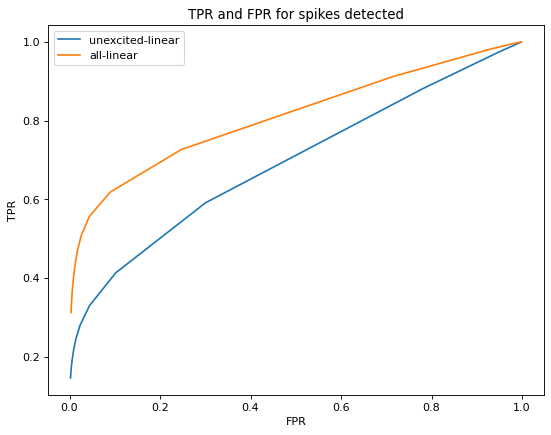

In [18]:
results_load = np.load('results/results_full.npy', allow_pickle=True).item()

# full data linear model vs non-input neurons only
plt.figure(figsize=(8,6), dpi=80)
plt.plot(results_load['fpr_noninput'],results_load['tpr_noninput'],label='unexcited-linear')
plt.plot(results_load['fpr'],results_load['tpr'],label='all-linear')
plt.title('TPR and FPR for spikes detected')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [19]:
results_load = np.load('results/results_full.npy', allow_pickle=True).item()

sorted_indices = np.argsort(results_load['fpr'])
fpr_sorted = np.array(results_load['fpr'])[sorted_indices]
tpr_sorted = np.array(results_load['tpr'])[sorted_indices]
sorted_indices_noninput = np.argsort(results_load['fpr_noninput'])
fpr_noninput_sorted = np.array(results_load['fpr_noninput'])[sorted_indices_noninput]
tpr_noninput_sorted = np.array(results_load['tpr_noninput'])[sorted_indices_noninput]

# Calculate AUROC for both curves using numerical integration
auroc = np.trapz(tpr_sorted, fpr_sorted)
auroc_noninput = np.trapz(tpr_noninput_sorted, fpr_noninput_sorted)

# # Store the AUROC values
# aurocs.append(auroc)
# aurocs_noninput.append(auroc_noninput)

print(f"AUROC is {auroc}")
print(f"AUROC_noninput is {auroc_noninput}")

AUROC is 0.8067839102164186
AUROC_noninput is 0.6910379225438986


Text(0.5, 1.0, 'Input')

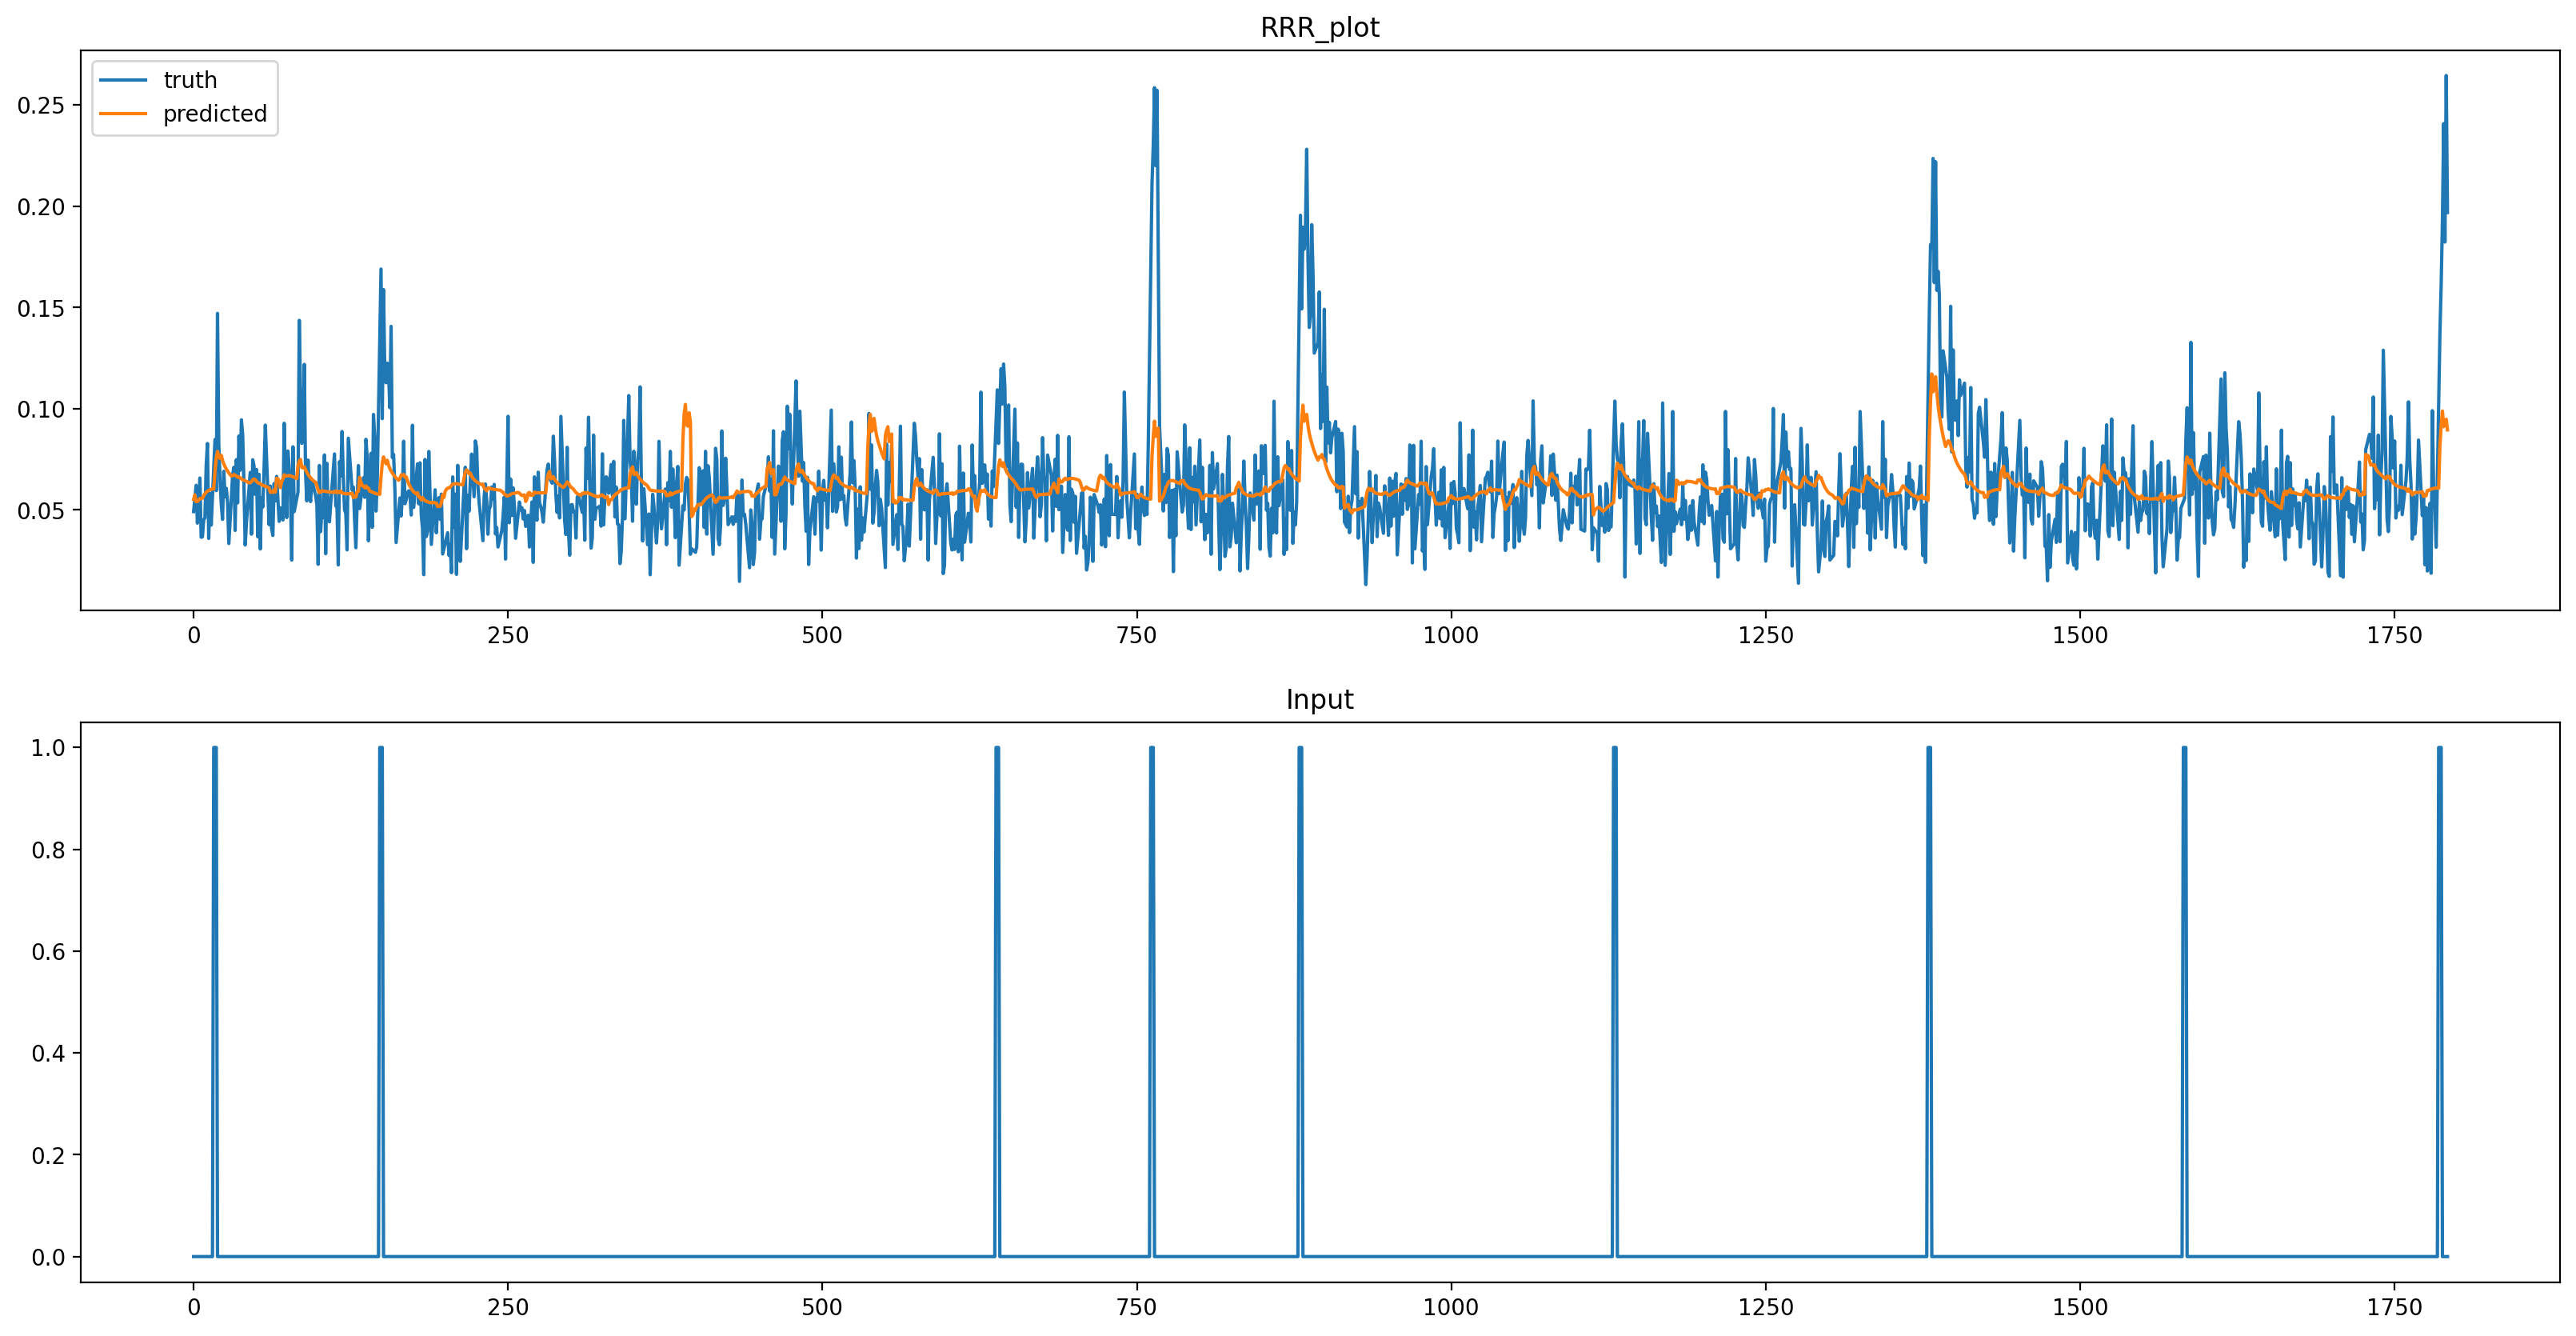

In [110]:
neuron = removed_neurons[9]
length = 50
t_start = 30

win_len = 25

output_pred = []
output_true = []
input_true = []
segment_marker = []

for i in range(t_start, t_start + win_len):
    output_pred.extend(x_pred[i][:,neuron])
    #output_pred.append(np.nan)
    output_true.extend(x_true[i][:,neuron])
    #output_true.append(np.nan)
    input_true.extend(u_true[i][:,neuron])
    #input_true.append(np.nan)
    segment_marker.extend(np.nan*np.zeros(len(x_pred[i][:,neuron])-1))
    segment_marker.extend([0.25,0])
    
plt.figure(figsize=(20,10))
plt.subplot(2,1,1)
plt.plot(output_true,label='truth')
plt.plot(output_pred,label='predicted')
#plt.plot(segment_marker)
plt.title('RRR_plot')
plt.legend()

plt.subplot(2,1,2)
plt.plot(input_true,label='input')
plt.title('Input')

Text(0.5, 1.0, 'Input')

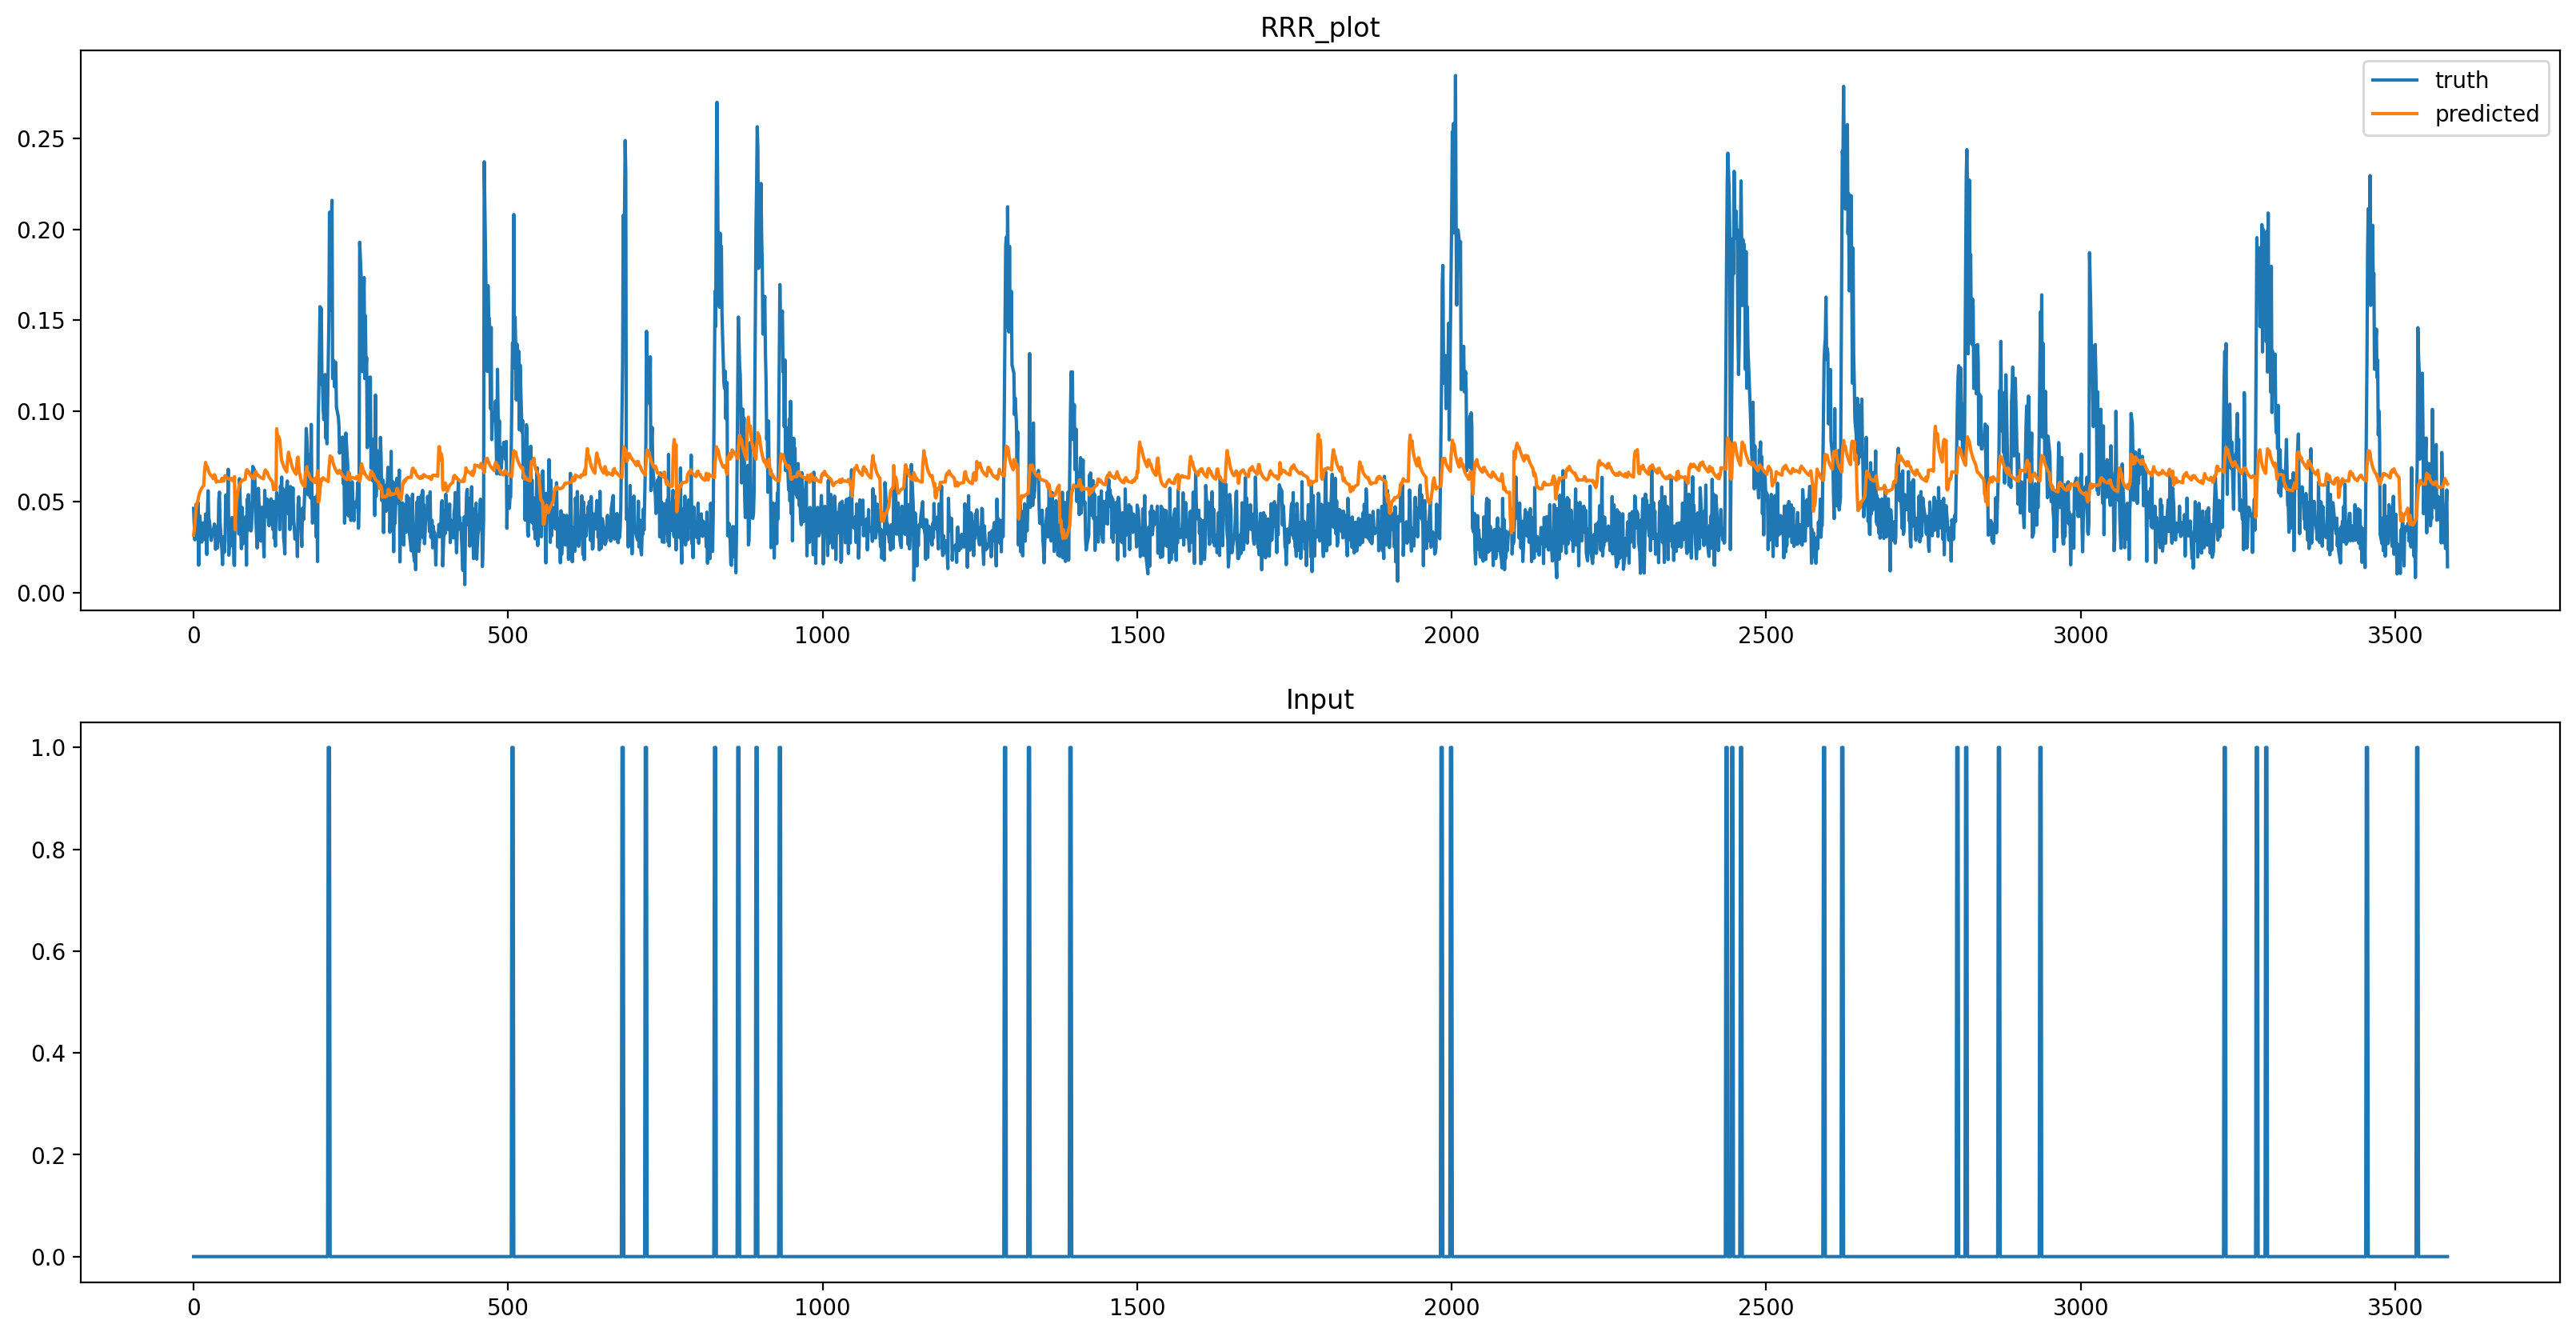

In [111]:
# linear model + gd + low rank init + low rank 35
neuron = removed_neurons[8]
length = 50
t_start = 30

output_pred = []
output_true = []
input_true = []
segment_marker = []

for i in range(t_start, t_start + np.min([len(x_true),length])):
    output_pred.extend(x_pred[i][:,neuron])
    #output_pred.append(np.nan)
    output_true.extend(x_true[i][:,neuron])
    #output_true.append(np.nan)
    input_true.extend(u_true[i][:,neuron])
    #input_true.append(np.nan)
    segment_marker.extend(np.nan*np.zeros(len(x_pred[i][:,neuron])-1))
    segment_marker.extend([0.25,0])
    
plt.figure(figsize=(20,10))
plt.subplot(2,1,1)
plt.plot(output_true,label='truth')
plt.plot(output_pred,label='predicted')
#plt.plot(segment_marker)
plt.title('RRR_plot')
plt.legend()

plt.subplot(2,1,2)
plt.plot(input_true,label='input')
plt.title('Input')